In [135]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tidigare information

In [136]:
mu_0 = 3
k_0 = 0.1

probability_prior = 0.5   # prior medelvärde
prior_sample_size = 2

h = 150  # mg/kg

# expert percentiler för sigma
expert_percentiler = {
"P01" : 0.35,
"P25" : 0.39,
"P50" : 0.41,
"P75" : 0.43,
"P99" : 0.48}

# tillväxvärde
growth_rate_mean = 0.2
growth_rate_var = 0.02
growth_noise_var = 0.01

# r ~ Normal(0.2, 0.02)
# epsilon_i ~ Normal(0, 0.01)

## Observerad data

In [137]:
def load_summary_data(filename):
    df = pd.read_csv(filename)
    row = df.iloc[0]

    data = {
        "n": int(row["n"]),
        "nonzero": int(row["nonzero"]),
        "fraction_nonzero": row["nonzero"] / row["n"],
        "m_logx": float(row["m_logx"]),
        "s2_logx": float(row["s2_logx"]),
    }

    return data


In [138]:
data = load_summary_data("studentid_me7337li.csv")

## Task 1 - Statistisk kalibrering

I denna del kalibreras modellen med hjälp av både observerad data och tidigare information. Modellen delas upp i två delar: sannolikheten att en ost är kontaminerad samt bakterienivån i kontaminerade ostar.

### Modell

Varje ost kan antingen vara kontaminerad eller inte. Detta modelleras med en sannolikhet $\theta$. Antalet kontaminerade ostar i ett stickprov följer därmed en binomialfördelning.

För de ostar som är kontaminerade modelleras bakteriekoncentrationen med en log-normalfördelning:

$$
\log X_i \sim N(\mu, \sigma)
$$

### Priorer

För sannolikheten $\theta$ används en Beta-fördelning eftersom dess x-värde går mellan 0 och 1:

$$
\theta \sim \text{Beta}(1,1)
$$

Denna prior är svagt informativ och speglar att vi initialt har begränsad kunskap om kontaminationssannolikheten.

För parametern $\mu$ används en normalfördelning (betingad på $\sigma$) med parametrar $\mu_0 = 3$ och $k_0 = 0.1$. Detta beskriver en initial uppfattning om den genomsnittliga logaritmen av bakterienivån.

För $\sigma$ används expertbedömningar. Givna kvantiler för $\sigma$ används tillsammans med SHELF-metoden för att anpassa en lämplig fördelning. En gammafördelning valdes för att representera denna osäkerhet eftersom den är definierad för positiva värden och gav en bra anpassning till de experteliciterade kvantilerna via SHELF.

### Uppdatering med data

Priorfördelningen för $\theta$ uppdateras med observerad data (antal kontaminerade ostar), vilket ger:

$$
\theta \mid \text{data} \sim \text{Beta}(14,8)
$$

Parametern $\mu$ uppdateras med hjälp av log-transformerade observationer, vilket ger uppdaterade parametrar $\mu_n$ och $k_n$.

Parametern $\sigma$ baseras på experteliciterade kvantiler som anpassats med hjälp av SHELF-metoden. För att möjliggöra en analytisk Bayesiansk uppdatering används en konjugat modell där osäkerheten i $\sigma$ uttrycks via en gammafördelning för $1/\sigma^2$, vilken därefter uppdateras med data.

Sammanfattningsvis består den kalibrerade modellen av en posteriorfördelning för $\theta$, uppdaterade parametrar för $\mu$, samt en uppdaterad beskrivning av osäkerheten i $\sigma$. Dessa används i de fortsatta simuleringarna.

Uppdatera theta (sannolikheten att en ost är smittad)

In [139]:
n = data["n"]
k = data["nonzero"]

#prior
alpha_0 = 0.5 * 2
beta_0 = (1 - 0.5) * 2

#post
alpha_post = alpha_0 + k
beta_post = beta_0 + (n - k)

print(f"Alpha posterior är {alpha_post} och beta posterior är {beta_post}")

Alpha posterior är 14.0 och beta posterior är 8.0


In [140]:
# transformerar sigma från percentiler för att passa modellen
def tranformation_sigma(percentiler):
    for p in percentiler:
        percentiler[p] = 1/(percentiler[p]**2)
    return percentiler

expert_percentiler = tranformation_sigma(expert_percentiler)
for p in expert_percentiler:
    print(f"{p} : {expert_percentiler[p]}")

P01 : 8.163265306122451
P25 : 6.574621959237343
P50 : 5.948839976204641
P75 : 5.408328826392645
P99 : 4.340277777777778


Kvantilerna för $\sigma$ transformerades till motsvarande kvantiler för $1/\sigma^2$, eftersom den konjugata modellen specificeras för denna storhet.

![SHELF prior](gamma_distribution.png)

In [141]:
# Prior för sigma från SHELF

alpha_prior = 48.7
beta_prior = 8.11

In [142]:
# Posterior för mu och sigma
n_pos = data["nonzero"]
xbar_log = data["m_logx"]
s2_log = data["s2_logx"]

# mu
mu_n = (k_0 * mu_0 + n_pos * xbar_log) / (k_0 + n_pos)
k_n = k_0 + n_pos

# sigma
alpha_n = alpha_prior + n_pos / 2
beta_n = (
    beta_prior
    + s2_log * (n_pos - 1) / 2
    + (n_pos * k_0 / (n_pos + k_0)) * (xbar_log - mu_0)**2 / 2
)

print(mu_n, k_n, alpha_n, beta_n)

3.68383361052236 13.1 55.2 8.778626655998314


## Task 2 - Visualisering av osäkerhet i $N_i^{24}$

I denna del studeras osäkerheten i bakteriekoncentrationen efter 24 timmar för enskilda ostar, $N_i^{24}$. Detta görs med hjälp av en tvåstegs Monte Carlo-simulering.

### Metod

Simuleringen delas upp i två nivåer:

- I den yttre loopen samplas osäkra modellparametrar från deras fördelningar, vilket representerar osäkerhet i modellen (osäkerhet).
- I den inre loopen simuleras variation mellan individuella ostar, exempelvis om en ost är kontaminerad samt variation i bakterietillväxt (variation).

För varje ost bestäms först om den är kontaminerad eller inte. För kontaminerade ostar simuleras en initial bakterienivå från en log-normalfördelning, varefter tillväxt över 24 timmar modelleras exponentiellt med en tillväxthastighet och slumpmässig variation.

### Resultat och visualisering

Resultatet visualiseras som en tvådimensionell fördelning där varje kurva representerar ett möjligt utfall av modellen. Figuren visar hur bakteriekoncentrationen varierar mellan ostar och hur osäkerheten i modellparametrarna påverkar resultatet.

Denna visualisering ger en intuitiv bild av både variationen mellan individuella ostar och den totala osäkerheten i modellen.

In [143]:
def simulate_N24(N_outer, N_inner,
                 mu_n, k_n, alpha_n, beta_n,
                 alpha_post, beta_post,
                 growth_rate_mean, growth_rate_var, growth_noise_var):

    """
    2D Monte Carlo: yttre = osäkerheten i parametrar, inner = variationen mellan ostar.
    Sparar en matris med formen (N_outer, N_inner) med antalet bakterier (mg / kg) för varje ost efter 24 timmar.
    """
    
    all_N24 = np.empty((N_outer, N_inner))

    for i in range(N_outer):
        # Yttre lopen
        precision = np.random.gamma(shape=alpha_n, scale=1/beta_n)
        sigma     = np.sqrt(1 / precision)
        mu        = np.random.normal(mu_n, sigma / np.sqrt(k_n))
        theta     = np.random.beta(alpha_post, beta_post)
        r         = np.random.normal(growth_rate_mean, np.sqrt(growth_rate_var))

        # Innre lopen
        infected = np.random.rand(N_inner) < theta
        log_N0   = np.random.normal(mu, sigma, N_inner)
        eps      = np.random.normal(0, np.sqrt(growth_noise_var), N_inner)
        all_N24[i] = np.where(infected, np.exp(log_N0 + (r + eps) * 24), 0)

    return all_N24

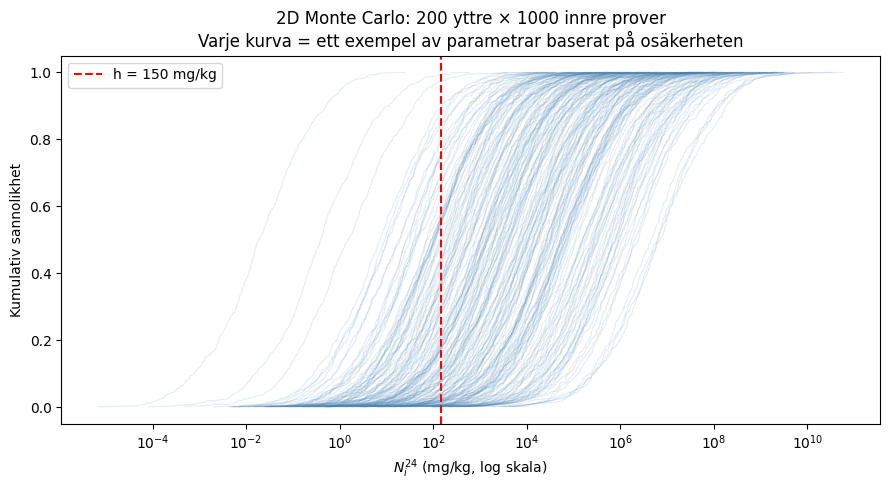

In [144]:
N_outer = 200   # Yttre
N_inner = 1000  # Innre

all_N24 = simulate_N24(
    N_outer, N_inner,
    mu_n, k_n, alpha_n, beta_n,
    alpha_post, beta_post,
    growth_rate_mean, growth_rate_var, growth_noise_var,
)

# Plottar resultatet
fig, ax = plt.subplots(figsize=(9, 5))

for row in all_N24:
    nonzero = row[row > 0]
    if len(nonzero) == 0:
        continue
    x = np.sort(nonzero)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, color="steelblue", alpha=0.15, linewidth=0.8)

ax.axvline(h, color="red", linestyle="--", label="h = 150 mg/kg")
ax.set_xscale("log")
ax.set_xlabel("$N_i^{24}$ (mg/kg, log skala)")
ax.set_ylabel("Kumulativ sannolikhet")
ax.set_title(f"2D Monte Carlo: {N_outer} yttre × {N_inner} innre prover\n"
             f"Varje kurva = ett exempel av parametrar baserat på osäkerheten")
ax.legend()
plt.tight_layout()
plt.show()

## Task 3 - Osäkerhet i $H_{24}$

I denna del studeras en sammanfattande storhet, $H_{24}$, som definieras som antalet ostar (av 1000) som överskrider gränsvärdet 150 mg/kg efter 24 timmar.

### Metod

För varje simulering räknas hur många ostar som har en bakteriekoncentration över gränsvärdet. Genom att upprepa simuleringen många gånger erhålls en fördelning för $H_{24}$, vilket gör det möjligt att kvantifiera osäkerheten i denna storhet.

### Resultat

Från simuleringarna beräknas:

- medelvärde  
- median  
- ett 95%-intervall  
- sannolikheten att fler än 50 ostar överskrider gränsvärdet  

Denna sannolikhet används direkt i beslutsregeln.

### Tolkning

Resultaten visar hur stor risken är att ett betydande antal ostar inte uppfyller säkerhetskraven. Genom att sammanfatta utfallet i $H_{24}$ fås ett tydligt mått som är direkt relevant för beslutsfattande.

Medelvärde:             506.3
Medianen:           544.0
95% intervall:     [57, 783]
P(H24 > 50):      0.978 (97.8%)
Ta bort från marknad: True


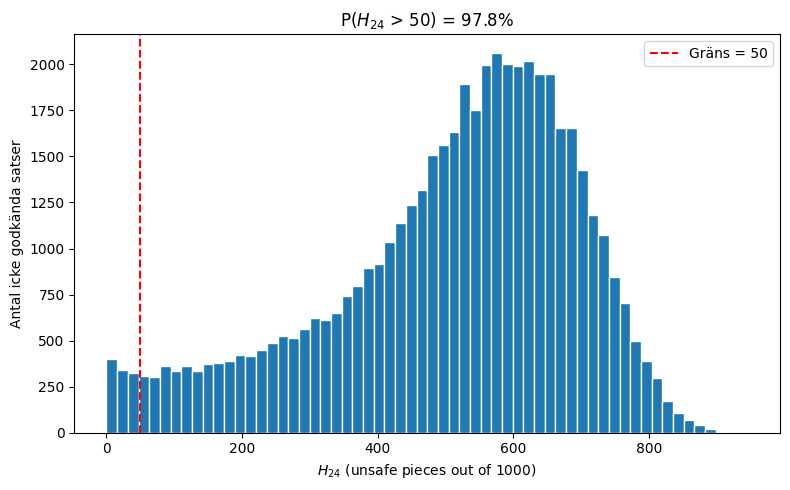

In [145]:
N_outer = 50000   # yttre
N_inner = 1000   # innre

all_N24 = simulate_N24(
    N_outer, N_inner,
    mu_n, k_n, alpha_n, beta_n,
    alpha_post, beta_post,
    growth_rate_mean, growth_rate_var, growth_noise_var,
)

H24_samples = (all_N24 > h).sum(axis=1)

print(f"Medelvärde:             {H24_samples.mean():.1f}")
print(f"Medianen:           {np.median(H24_samples):.1f}")
print(f"95% intervall:     [{np.percentile(H24_samples, 2.5):.0f}, {np.percentile(H24_samples, 97.5):.0f}]")
prob = np.mean(H24_samples > 50)
print(f"P(H24 > 50):      {prob:.3f} ({prob*100:.1f}%)")
print(f"Ta bort från marknad: {prob > 0.60}")

plt.figure(figsize=(8, 5))
plt.hist(H24_samples, bins=60, edgecolor="white")
plt.axvline(50, color="red", linestyle="--", label="Gräns = 50")
plt.xlabel("$H_{24}$ (unsafe pieces out of 1000)")
plt.ylabel("Antal icke godkända satser")
plt.title(f"P($H_{{24}}$ > 50) = {prob*100:.1f}%")
plt.legend()
plt.tight_layout()
plt.show()

## Task 4 – Slutsats

Syftet med denna analys är att bedöma risken att ett parti ost inte uppfyller säkerhetskraven efter 24 timmar. Detta görs genom att studera sannolikheten att fler än 50 av 1000 ostar överskrider gränsvärdet 150 mg/kg.

Simuleringen visar att medelvärdet av $H_{24}$ är **506.3**, med en median på **544.0** och ett 95%-intervall på **[57, 783]**. Sannolikheten att fler än 50 ostar överskrider gränsvärdet uppskattas till:

$$
P(H_{24} > 50) = 97.8\%
$$

Enligt beslutsregeln ska partiet tas bort från marknaden om denna sannolikhet överstiger 60%.

Eftersom sannolikheten är **större** än 0.60 innebär detta att partiet **bör tas bort från** marknaden.

### Tolkning

Resultatet tar hänsyn till både osäkerhet i modellparametrar och variation mellan individuella ostar. Detta innebär att slutsatsen inte baseras på ett enskilt scenario, utan på en samlad bedömning av möjliga utfall.

Analysen visar att risken för att ett stort antal ostar överskrider säkerhetsgränsen är **hög**, vilket ligger till grund för det slutliga beslutet.